In [ ]:
import sinter
import stim
from typing import List
from mwpf import SinterMWPFDecoder
import matplotlib.pyplot as plt

In [73]:
noise = [0.01, 0.05, 0.08, 0.1, 0.2]
code_distance = [3, 5, 7, 9]
MAX_SHOTS = 100000
MAX_ERRORS = 1000

In [76]:
# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
task_configs = [
    dict(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 2,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={"d": d, "p": p, "label": "rotated_memory_x"},
    )
    for d in code_distance
    for p in noise
]

tasks = [sinter.Task(**task) for task in task_configs]

pymatching_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=10,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=MAX_SHOTS,
    max_errors=MAX_ERRORS,
    count_observable_error_combos=True,
    count_detection_events=True,
)

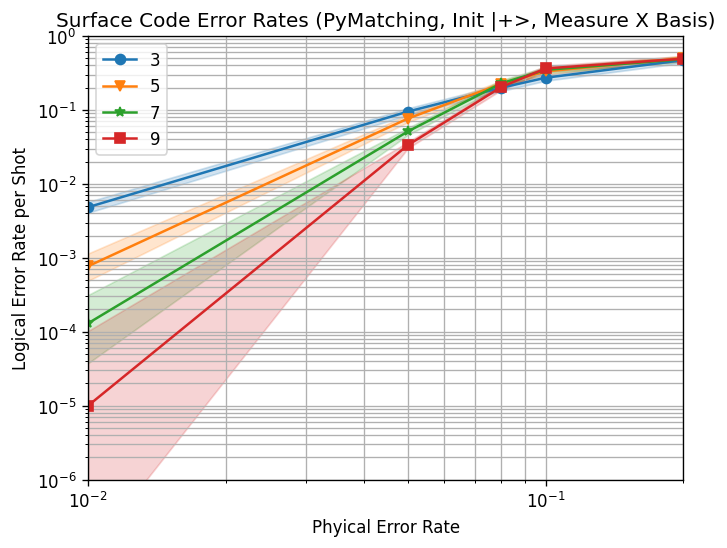

In [77]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
ax.set_ylim(1e-6, 1e0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title("Surface Code Error Rates (PyMatching, Init |+>, Measure X Basis)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

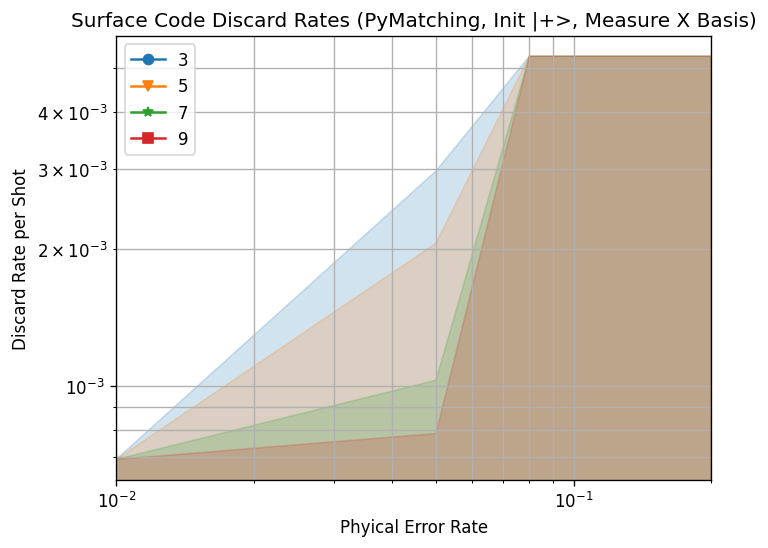

In [61]:
fig, ax = plt.subplots(1, 1)
sinter.plot_discard_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
# ax.set_ylim(1e-1, 1e-0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title("Surface Code Discard Rates (PyMatching, Init |+>, Measure X Basis)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Discard Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [74]:
# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
task_configs = [
    dict(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 2,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={"d": d, "p": p, "label": "rotated_memory_x"},
    )
    for d in code_distance
    for p in noise
]

tasks = [sinter.Task(**task) for task in task_configs]

mwpf_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=10,
    tasks=tasks,
    decoders=["mwpf"],
    custom_decoders={
        "mwpf": SinterMWPFDecoder(cluster_node_limit=50, with_progress=True)
    },
    max_shots=MAX_SHOTS,
    max_errors=MAX_ERRORS,
    print_progress=True,
    count_observable_error_combos=True,
    count_detection_events=True,
)

Starting 10 workers...
20 tasks left:
  workers decoder eta shots_left errors_left json_metadata                    
        1    mwpf <1m      98703         996 d=3,p=0.01,label=rotated_memory_x
        1    mwpf   ?     100000        1000 d=3,p=0.05,label=rotated_memory_x
        1    mwpf   ?     100000        1000 d=3,p=0.08,label=rotated_memory_x
        1    mwpf   ?     100000        1000 d=3,p=0.1,label=rotated_memory_x 
        1    mwpf   ?     100000        1000 d=3,p=0.2,label=rotated_memory_x 
        1    mwpf   ?     100000        1000 d=5,p=0.01,label=rotated_memory_x
        1    mwpf   ?     100000        1000 d=5,p=0.05,label=rotated_memory_x
        1    mwpf   ?     100000        1000 d=5,p=0.08,label=rotated_memory_x
        1    mwpf   ?     100000        1000 d=5,p=0.1,label=rotated_memory_x 
        1    mwpf   ?     100000        1000 d=5,p=0.2,label=rotated_memory_x 
        0    mwpf ?·∞     100000        1000 d=7,p=0.01,label=rotated_memory_x
        0    m

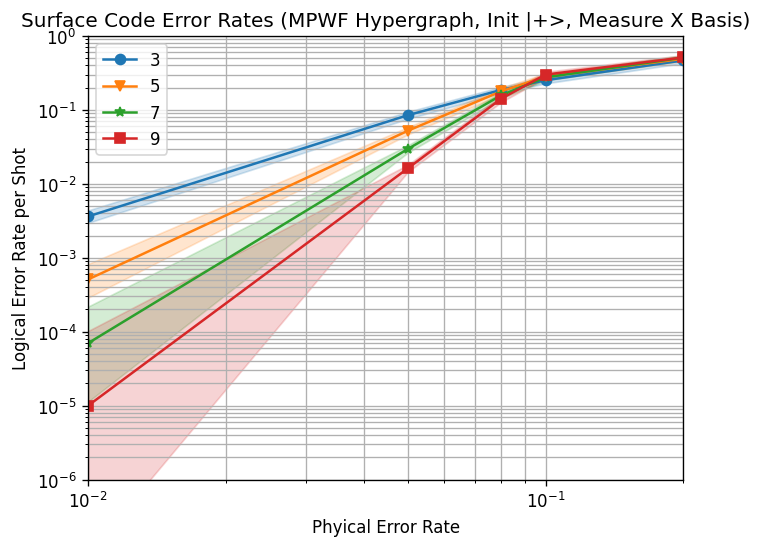

In [78]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=mwpf_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
ax.set_ylim(1e-6, 1e0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title("Surface Code Error Rates (MPWF Hypergraph, Init |+>, Measure X Basis)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

In [ ]:
import itertools
from uuid import uuid4


from dataclasses import replace
import mwpf.ref_circuit

# TODO - if we use individual errors e.g. X_ERROR Y_ERROR Z_ERROR instead of randomized DEPOLARIZE1/2 noise
CONVERT_TO_ERASURE_NOISE = ("DEPOLARIZE1", "DEPOLARIZE2")
noise = [0.01, 0.05, 0.08, 0.1, 0.2]
code_distance = [3, 5, 7, 9]


def erasure_conversion(
    task_config: dict, conversion_factor: int = 1, add_detectors: bool = True
) -> dict:
    """Converts random pauli noise instructions (e.g. DEPOLARIZE1, DEPOLARIZE2) to HERALDED_ERASE instructions

    See notes in https://github.com/yuewuo/mwpf/blob/main/src/python/mwpf/ref_circuit.py
    for explanation of why reference circuits are needed to keep track of measurement indices w/ heralded errors
    """
    circuit = task_config["circuit"]
    json_metadata = task_config["json_metadata"]
    ref_circuit = mwpf.ref_circuit.RefCircuit.of(circuit)

    instructions: list[mwpf.ref_circuit.RefInstruction] = []
    for instruction in ref_circuit:
        if instruction.name in CONVERT_TO_ERASURE_NOISE:
            p = instruction.gate_args[0]
            instructions.append(replace(instruction, gate_args=[p * conversion_factor]))
            # new_instruction = mwpf.ref_circuit.RefInstruction.new_heralded_erase(
            #     instruction.targets, min(1, 4 / 3 * p * conversion_factor)
            # )
            new_instruction = mwpf.ref_circuit.RefInstruction.new_heralded_erase(
                instruction.targets, p * conversion_factor
            )
            instructions.append(new_instruction)
            if add_detectors is True:
                for rec in new_instruction.recs:
                    instructions.append(
                        mwpf.ref_circuit.RefInstruction.new_detector((rec,))
                    )
        else:
            instructions.append(instruction)
    converted_metadata = json_metadata.copy()
    converted_metadata["p_erase"] = converted_metadata["p"]
    converted_metadata["p"] = 0
    run_id = converted_metadata["run_id"]

    converted_circuit = mwpf.ref_circuit.RefCircuit.of(instructions).circuit()
    new_task_config = dict(
        circuit=converted_circuit,
        json_metadata=converted_metadata,
        decoder=f"mwpf__{run_id}",
    )
    return new_task_config


# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
task_configs = [
    [
        dict(
            circuit=stim.Circuit.generated(
                "surface_code:rotated_memory_x",
                rounds=d * 2,
                distance=d,
                before_round_data_depolarization=p,
            ),
            json_metadata={
                "d": d,
                "p": p,
                "label": "rotated_memory_x",
                "run_id": str(uuid4()),
            },
        )
        for p in noise
    ]
    for d in code_distance
]
converted_erasure_task_configs = list(map(erasure_conversion, task_configs))
tasks = [sinter.Task(**task) for task in converted_erasure_task_configs]


def build_custom_decoders(task_configs):
    return {
        f"mwpf__{task_config['json_metadata']['run_id']}": SinterMWPFDecoder(
            cluster_node_limit=50, with_progress=True, timeout=3
        ).with_circuit(task_config["circuit"])
        for task_config in task_configs
    }


# def sinter_with_custom_decoder(task_config: dict):
#     task = sinter.Task(**task_config)
#     result = sinter.collect(
#         num_workers=1,
#         tasks=[task],
#         custom_decoders = custom_decoders(converted_erasure_task_configs)
#         max_shots=10000,
#         max_errors=100,
#         print_progress=True
#     )
#     return result


erasure_collected_stats = []
for cfg in task_configs:
    result = sinter.collect(
        num_workers=8,
        tasks=tasks,
        custom_decoders=build_custom_decoders(converted_erasure_task_configs),
        count_observable_error_combos=True,
        count_detection_events=True,
        print_progress=True,
        max_shots=MAX_SHOTS,
        max_errors=MAX_ERRORS,
        save_resume_filepath=f"/Users/leigh/edu/cal/C191A-project/tmp/surface_code_x_rotated_memory_v1__d={cfg['d']}",
    )
    erasure_collected_stats.append(result)

Starting 10 workers...
20 tasks left:
  workers                                    decoder eta shots_left errors_left json_metadata                                                                          
        1 mwpf__e2f1f958-6783-494f-b39b-f5a9126923a7   ?     100000        1000 d=3,p=0,label=rotated_memory_x,run_id=e2f1f958-6783-494f-b39b-f5a9126923a7,p_erase=0.01
        1 mwpf__bb349f9b-5fea-4331-9dea-667ae05abd60 <1m      99727         965 d=3,p=0,label=rotated_memory_x,run_id=bb349f9b-5fea-4331-9dea-667ae05abd60,p_erase=0.05
        1 mwpf__31d669b6-a583-4b79-96ea-d48440cd2461   ?     100000        1000 d=3,p=0,label=rotated_memory_x,run_id=31d669b6-a583-4b79-96ea-d48440cd2461,p_erase=0.08
        1 mwpf__a41a8b7a-8375-4a23-91bd-eb545cad92dd   ?     100000        1000 d=3,p=0,label=rotated_memory_x,run_id=a41a8b7a-8375-4a23-91bd-eb545cad92dd,p_erase=0.1 
        1 mwpf__8bc6356e-d9ef-4d82-9c95-eb242d16e778   ?     100000        1000 d=3,p=0,label=rotated_memory_x,run_id=8bc6

KeyboardInterrupt: 

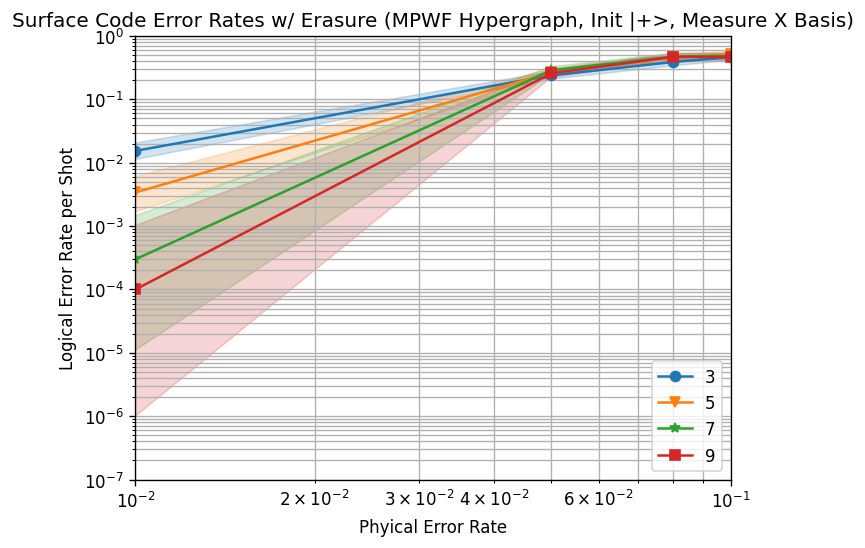

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=erasure_collected_stats,
    x_func=lambda stats: stats.json_metadata["p_erase"],
    group_func=lambda stats: stats.json_metadata["d"],
)
ax.set_ylim(1e-7, 1e-0)
ax.set_xlim(1e-2, 1e-1)
ax.loglog()
ax.set_title(
    "Surface Code Error Rates w/ Erasure (MPWF Hypergraph, Init |+>, Measure X Basis)"
)
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)

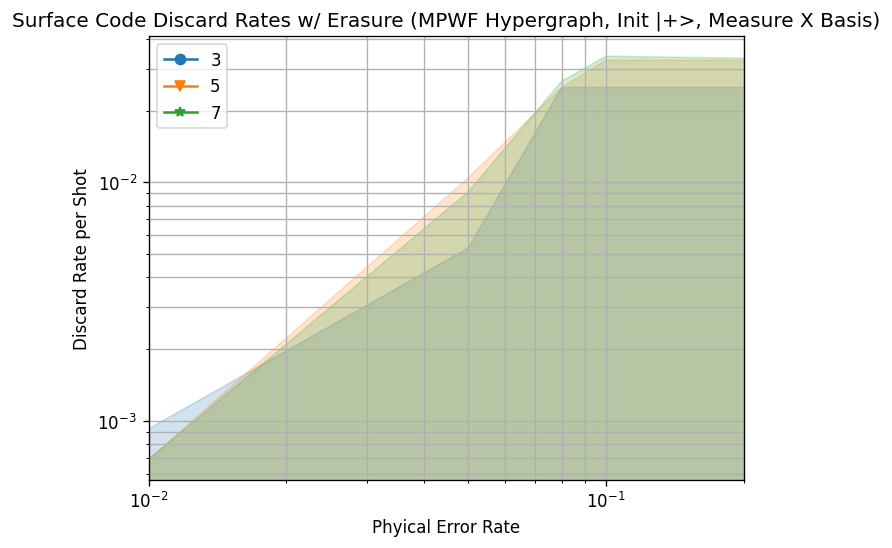

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_discard_rate(
    ax=ax,
    stats=erasure_collected_stats,
    x_func=lambda stats: stats.json_metadata["p_erase"],
    group_func=lambda stats: stats.json_metadata["d"],
)
# ax.set_ylim(1e-1, 1e-0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title(
    "Surface Code Discard Rates w/ Erasure (MPWF Hypergraph, Init |+>, Measure X Basis)"
)
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Discard Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)